# Exercise - Swaption Vol Skew


#### Notation Commands

$$\newcommand{\Black}{\mathcal{B}}
\newcommand{\Blackcall}{\Black_{\mathrm{call}}}
\newcommand{\Blackput}{\Black_{\mathrm{put}}}
\newcommand{\EcondS}{\hat{S}_{\mathrm{conditional}}}
\newcommand{\Efwd}{\mathbb{E}^{T}}
\newcommand{\Ern}{\mathbb{E}^{\mathbb{Q}}}
\newcommand{\Tfwd}{T_{\mathrm{fwd}}}
\newcommand{\Tunder}{T_{\mathrm{bond}}}
\newcommand{\accint}{A}
\newcommand{\carry}{\widetilde{\cpn}}
\newcommand{\cashflow}{C}
\newcommand{\convert}{\phi}
\newcommand{\cpn}{c}
\newcommand{\ctd}{\mathrm{CTD}}
\newcommand{\disc}{Z}
\newcommand{\done}{d_{1}}
\newcommand{\dt}{\Delta t}
\newcommand{\dtwo}{d_{2}}
\newcommand{\flatvol}{\sigma_{\mathrm{flat}}}
\newcommand{\flatvolT}{\sigma_{\mathrm{flat},T}}
\newcommand{\float}{\mathrm{flt}}
\newcommand{\freq}{m}
\newcommand{\futprice}{\mathcal{F}(t,T)}
\newcommand{\futpriceDT}{\mathcal{F}(t+h,T)}
\newcommand{\futpriceT}{\mathcal{F}(T,T)}
\newcommand{\futrate}{\mathscr{f}}
\newcommand{\fwdprice}{F(t,T)}
\newcommand{\fwdpriceDT}{F(t+h,T)}
\newcommand{\fwdpriceT}{F(T,T)}
\newcommand{\fwdrate}{f}
\newcommand{\fwdvol}{\sigma_{\mathrm{fwd}}}
\newcommand{\fwdvolTi}{\sigma_{\mathrm{fwd},T_i}}
\newcommand{\grossbasis}{B}
\newcommand{\hedge}{\Delta}
\newcommand{\ivol}{\sigma_{\mathrm{imp}}}
\newcommand{\logprice}{p}
\newcommand{\logyield}{y}
\newcommand{\mat}{(n)}
\newcommand{\nargcond}{d_{1}}
\newcommand{\nargexer}{d_{2}}
\newcommand{\netbasis}{\tilde{\grossbasis}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\notional}{K}
\newcommand{\pfwd}{P_{\mathrm{fwd}}}
\newcommand{\pnl}{\Pi}
\newcommand{\price}{P}
\newcommand{\probexer}{\hat{\mathcal{P}}_{\mathrm{exercise}}}
\newcommand{\pvstrike}{K^*}
\newcommand{\refrate}{r^{\mathrm{ref}}}
\newcommand{\rrepo}{r^{\mathrm{repo}}}
\newcommand{\spotrate}{r}
\newcommand{\spread}{s}
\newcommand{\strike}{K}
\newcommand{\swap}{\mathrm{sw}}
\newcommand{\swaprate}{\cpn_{\swap}}
\newcommand{\tbond}{\mathrm{fix}}
\newcommand{\ttm}{\tau}
\newcommand{\value}{V}
\newcommand{\vega}{\nu}
\newcommand{\years}{\tau}
\newcommand{\yearsACT}{\tau_{\mathrm{act/360}}}
\newcommand{\yield}{Y}$$


## Swaption Vol Data

The file `data/swaption_vol_data_2025-06-30.xlsx` has market data on the implied volatility skews for swaptions. Note that it has several columns:
* `expry`: expiration of the swaption
* `tenor`: tenor of the underlying swap
* `model`: the model by which the volatility is quoted. (All are Black.)
* `-200`, `-100`, etc.: The strike listed as difference from ATM strike (bps). Note that ATM is considered to be the **forward swapa rate** which you can calculate.


Your data: you will use a single row of this data for the `1x4` swaption.
* date: `2025-06-30`
* expiration: 1yr
* tenor: 4yrs


## Rate Data

The file `data/cap_curves_2025-06-30.xlsx` gives 
* SOFR swap rates, 
* their associated discount factors
* their associated forward interest rates.

You will not need the cap data (flat or forward vols) for this problem.


## The Swaption

Consider the following swaption with the following features:
* underlying is a fixed-for-floating (SOFR) swap
* the underlying swap has **quarterly** payment frequency
* this is a **payer** swaption, which gives the holder the option to **pay** the fixed swap rate and receive SOFR.


### SABR Model

Use the quoted volatility skew to fit a SABR model.
* Throughout, parameterize, `beta=.75`.


In [ ]:
import pandas as pd
import numpy as np
curve = pd.read_excel('data/cap_curves_2025-06-30.xlsx')
swaption_data = pd.read_excel('data/swaption_vol_data_2025-06-30.xlsx')

### 1.1.
Estimate $(\alpha,\rho,\nu)$ via the SABR formula. Feel free to use the `sabr` function in `cmds/volskew.py`.

Report the values of these parameters.


In [ ]:
import numpy as np
from scipy.optimize import minimize
from numpy.polynomial import polynomial as P


############################
# Market Data
############################

f = 0.038115
beta = 0.75
T = 1.0

# bp strike shifts
shifts = np.array([-200,-100,-50,-25,0,25,50,100,200]) / 10000.0
strikes = f + shifts

# 1Y x 1Y smile (row 0)
vols_bp = np.array([54.405, 38.565, 33.925, 32.195, 30.83, 29.805, 29.095, 28.43, 28.885])

vols = vols_bp / 100.0   # convert bp → decimal
volATM = vols[4]


############################
# SABR FUNCTIONS
############################

def sabr_atm(beta, alpha, nu, rho, f, T):
    """Hagan ATM expansion"""
    term = (
        ((1-beta)**2 / 24) * (alpha**2 / f**(2-2*beta)) +
        (rho*beta*nu*alpha)/(4*f**(1-beta)) +
        (2-3*rho**2)/24 * nu**2
    )
    return alpha/f**(1-beta) * (1 + term*T)


def solve_alpha(beta, nu, rho, T, volATM, f):
    """
    Solve cubic for alpha from ATM formula
    """
    c3 = (1-beta)**2 * T / (24 * f**(2-2*beta))
    c2 = rho*beta*nu*T / (4 * f**(1-beta))
    c1 = 1 + (2-3*rho**2)*nu**2*T/24
    c0 = -volATM * f**(1-beta)

    roots = P.polyroots([c0, c1, c2, c3])
    roots = roots[np.isreal(roots)].real
    return roots[roots > 0][0]


def sabr_vol(beta, alpha, nu, rho, f, K, T):

    if np.isclose(K, f):
        return sabr_atm(beta, alpha, nu, rho, f, T)

    logFK = np.log(f/K)

    z = (nu/alpha) * (f*K)**((1-beta)/2) * logFK
    chi = np.log((np.sqrt(1-2*rho*z+z**2) + z - rho)/(1-rho))

    num = alpha * (
        1 +
        (
            ((1-beta)**2/24)*(alpha**2/(f*K)**(1-beta)) +
            (rho*beta*nu*alpha)/(4*(f*K)**((1-beta)/2)) +
            (2-3*rho**2)/24*nu**2
        ) * T
    )

    den = (f*K)**((1-beta)/2) * (
        1 +
        ((1-beta)**2/24)*logFK**2 +
        ((1-beta)**4/1920)*logFK**4
    )

    return num/den * z/chi


############################
# CALIBRATION
############################

def objective(x):
    nu, rho = x

    # enforce reasonable bounds
    if nu <= 0 or abs(rho) >= 1:
        return 1e6

    alpha = solve_alpha(beta, nu, rho, T, volATM, f)

    model = np.array([
        sabr_vol(beta, alpha, nu, rho, f, K, T)
        for K in strikes
    ])

    return np.sum((model - vols)**2)


result = minimize(
    objective,
    x0=[0.7, -.6],
    bounds=[(1e-4,5), (-0.999,0.999)]
)

nu_star, rho_star = result.x
alpha_star = solve_alpha(beta, nu_star, rho_star, T, volATM, f)


print("Calibrated Parameters")
print("---------------------")
print("alpha:", alpha_star)
print("nu   :", nu_star)
print("rho  :", rho_star)
print("SSE  :", result.fun)


Calibrated Parameters
---------------------
alpha: 0.13225124863208074
nu   : 0.8964932748451666
rho  : -0.40749036993866034
SSE  : 0.0002733335794880038


### 1.2.
Create a grid of strikes of `[.0025, .09]`, with grid spacing of `10bps`, (.0010).

Use the SABR model parameterized above to calculate the volatility for each of these strikes.

* Plot the SABR curve, and also include the market quotes in the plot.

* Conceptually, does the SABR curve fit these points well? Perfectly?


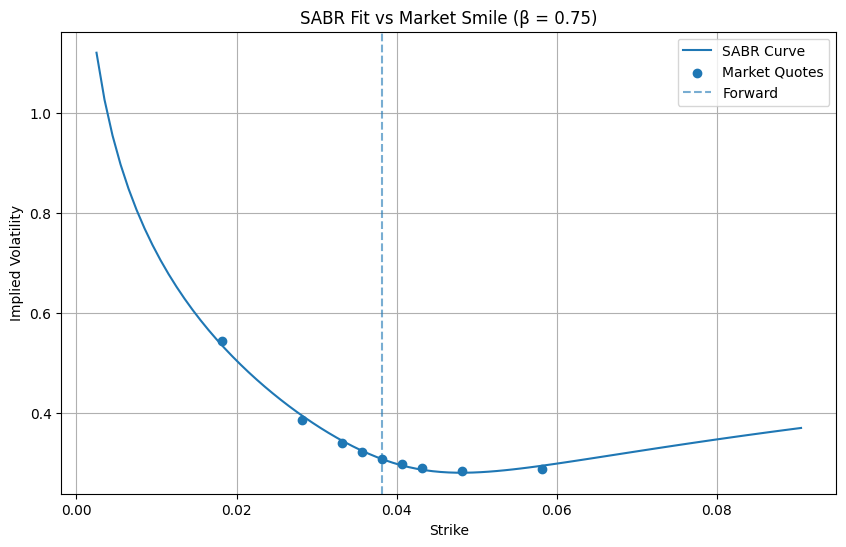

In [5]:
import matplotlib.pyplot as plt

############################
# STRIKE GRID
############################

K_grid = np.arange(0.0025, 0.0900 + 0.0010, 0.0010)

sabr_curve = np.array([
    sabr_vol(beta, alpha_star, nu_star, rho_star, f, K, T)
    for K in K_grid
])

############################
# PLOT
############################

plt.figure(figsize=(10,6))

# SABR smooth curve
plt.plot(K_grid, sabr_curve, label="SABR Curve")

# Market quotes
plt.scatter(strikes, vols, zorder=3, label="Market Quotes")

plt.axvline(f, linestyle="--", alpha=0.6, label="Forward")

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("SABR Fit vs Market Smile (β = 0.75)")
plt.legend()
plt.grid(True)

plt.show()

### 1.3.
Suppose we want to price the `1y4y` swaption but with a far out-of-the-money strike of `5%`. 

* Use the SABR vol at this strike to price the swaption.

(Note that this strike is far outside the range for which we have market quotes, and even if we do have quotes, they likely are not liquid on a given day.)


In [7]:
from scipy.stats import norm
vol = sabr_vol(beta, alpha_star, nu_star, rho_star, f, .05, T)
print("SABR Implied Vol at K=5%:", vol)
n = 4
fwd_swap_rate = n*(0.962807 - 0.844989)/(curve['discounts'].iloc[4:20].sum())
P = curve['discounts'].iloc[4:20].sum()*.25
strikes = [.05]
implied_vols = [vol*100]  
for i in range(len(strikes)):
    d1 = (np.log(fwd_swap_rate/strikes[i]) + 0.5*(implied_vols[i]/100)**2)/(implied_vols[i]/100)
    d2 = d1 - implied_vols[i]/100
    price = 100*P*((fwd_swap_rate*norm.cdf(d1) - strikes[i]*norm.cdf(d2)))
    print(f'Strike: {strikes[i]:.4f}, Price: ${price:.2f}')

SABR Implied Vol at K=5%: 0.28139633568682126
Strike: 0.0500, Price: $0.12


### 1.4.

Use the ATM implied volatility to fit $\alpha$, (sometimes denoted $\sigma_0$.) That is, for any choice of $(\rho,\nu)$, solve a quadratic equation to get $\alpha$ as a function of those two parameters, along with $\beta$, which is at its selected (not estimated) value.

Recall that we have a simple relationship between ATM vol and $\alpha$.

$$\sigma_\text{ATM} = \alpha\frac{B}{F^{1-\beta}}$$
where $B$ is defined in the discussion note. It is a quadratic expression of $\alpha$ along with $(\beta,\rho,\nu)$.

This decouples the optimization. We solve for $(\rho,\nu)$ and $\alpha$ as a function of the other two parameters.

Consider using the function `sabrATM` in `cmds/volskew.py`.


In [8]:
import numpy.polynomial.polynomial as poly
def solve_alpha(beta, nu, rho, T, volATM, f):
    coefs = np.ones(4) 
    coefs[3] = (1-beta)**2 * T / (24*f**(2-2*beta)) 
    coefs[2] = rho * beta * nu * T / (4*f**(1-beta)) 
    coefs[1] = 1 + (2-3*rho**2) * nu**2 * T / 24 
    coefs[0] = -volATM * f**(1-beta) 
    roots = poly.polyroots(coefs) 
    alpha = np.real(roots[np.abs(np.imag(roots))<1e-6][0]) 
    return alpha

alpha = solve_alpha(beta, nu_star, rho_star, T, volATM, f)
alpha

np.float64(0.13225124863208074)

# 2. SABR and Risk Management


Consider how an **increase** of `50bps` in the underlying rate impacts the price of the `1y4y` ATM swaption.

Here, we are assuming that
* the rate change will impact the forward swap rate directly, one-for-one with other rates.
* the shift happens one week after the original quote date.

Of course, in reality, a rate change
* may price in early to some degree if it is expected
* may not impact the forward swap rate one-for-one. We would need to model how the discount curve changes and what that change (level, slope, curvature?) would do to the forward swap rate.


### 2.1

Use Black's equation to re-price the `1y4y` swaption with
* the same ATM volatility
* an underlying (forward swap) rate `increased` `50bps`.
* the same time-to-maturities. (We should decrease these all by 1/365, but we focus here on the delta effects rather than the theta. And it would be a small impact anyone.)

Report 
* the new price
* the change in price divided by `50bps`, (a numerical delta.)


### 2.2

Now, we consider how the volatility may change with the underlying shift `up` of `50bps`.

Using the same SABR parameters from `2.1`, and the strike grid from `2.2`, plot the new SABR curve accounting for the underlying rate shifting `up` `50bps`.


### 2.3

Calculate the new volatility specifically for the pre-shift ATM strike.

Use this in Black's formula similar to `3.1`, where the only change is the volatility now reflects the shift in the underlying (not the strike).

Report
* the new price
* the change in price divided by `50bps`


### 2.4

How much different is the (dynamic) delta which accounts for the shift in volatility from the (static) delta in `3.1`?
